Importing All the required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import data
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [16]:
print("gender", df['gender'].unique())
print("Ethnicity", df['race/ethnicity'].unique())
print("parental level of education	", df['parental level of education'].unique())
print("test preparation course", df['test preparation course'].unique())


gender ['female' 'male']
Ethnicity ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education	 ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
test preparation course ['none' 'completed']


In [18]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "O"]


print("numeric_features", numeric_features)
print("categorical_features", categorical_features)

numeric_features ['math score', 'reading score', 'writing score']
categorical_features ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [19]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [22]:
df["total score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average"] = df["total score"]/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score']==100]["average"].count()
math_full = df[df["math score"]==100]["average"].count()

print("reading full Marks: ", reading_full)
print("writing full Marks: ", writing_full)
print("Math Full Marks: ", math_full)

reading full Marks 17
writing full Marks 14
Math Full Marks 7


In [27]:
reading_less_20 = df[df["reading score"]<=20]["average"].count()
writing_less_20 = df[df["writing score"]<=20]["average"].count()
math_less_20 = df[df["math score"]<=20]["average"].count()

print("reading <= 20 Marks: ", reading_less_20)
print("writing <= 20 Marks: ", writing_less_20)
print("Math <=20 Marks: ", math_less_20)


reading <= 20 Marks:  1
writing <= 20 Marks:  3
Math <=20 Marks:  4


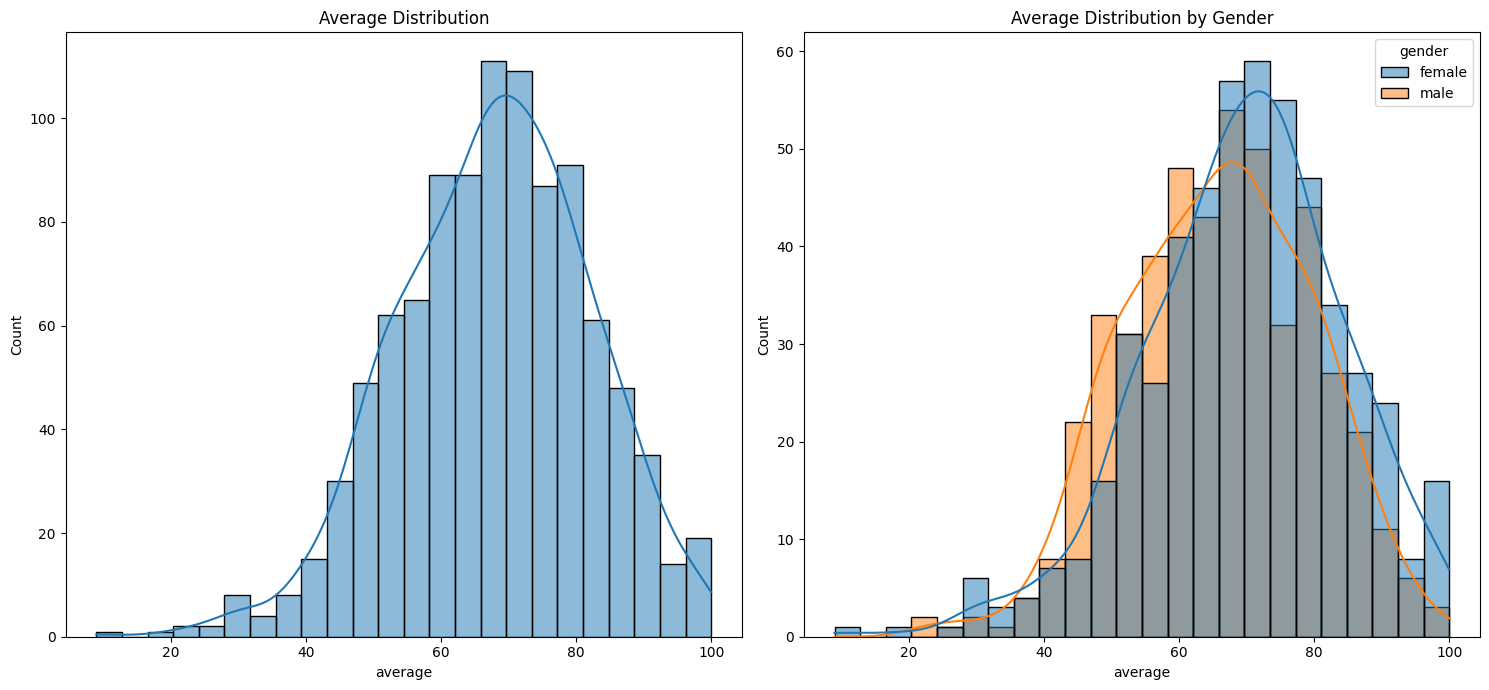

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1
sns.histplot(data=df, x="average", kde=True, ax=axs[0])
axs[0].set_title("Average Distribution")

# Plot 2
sns.histplot(data=df, x="average", kde=True, hue="gender", ax=axs[1])
axs[1].set_title("Average Distribution by Gender")

plt.tight_layout()
plt.show()